# CohortX Task 2 — self-contained statistical verification

This notebook is designed to run with **only** `Solution.csv` and the nine participant submission CSV files in the working directory.

In [ ]:
from pathlib import Path
import re, math, warnings
from difflib import SequenceMatcher
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

BASE = Path('.')
OUT = BASE / 'computed_outputs'
OUT.mkdir(exist_ok=True)
RANDOM_SEED = 20260817
SCALE = 1.024
FILES = {
    'Alan T. Andrea': 'Alan T. Andrea.csv',
    'Harsh Rajbhar': 'Harsh Rajbhar.csv',
    'Jason Karpeles': 'Jason Karpeles.csv',
    'Flan': 'Kirscher.csv',
    'Mohit': 'Mohit.csv',
    'NTUA': 'NTUA.csv',
    'Ngoc': 'Ngọc Hưng Nguyễn.csv',
    'RIN THIRA': 'RIN THIRA.csv',
    'Yingfali': 'Yingfali.csv',
}
PRIVATE_INDICES = np.arange(25)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi':120,'savefig.dpi':300,'font.size':10,'axes.titleweight':'bold'})


def hungarian_max(matrix):
    """Return a maximum-weight assignment as (row_indices, col_indices). Pure Python."""
    a=np.asarray(matrix,dtype=float)
    transposed=False
    if a.shape[0]>a.shape[1]:
        a=a.T; transposed=True
    n,m=a.shape
    cost=-a
    u=np.zeros(n+1); v=np.zeros(m+1); p=np.zeros(m+1,dtype=int); way=np.zeros(m+1,dtype=int)
    for i in range(1,n+1):
        p[0]=i; j0=0; minv=np.full(m+1,np.inf); used=np.zeros(m+1,dtype=bool)
        while True:
            used[j0]=True; i0=p[j0]; delta=np.inf; j1=0
            for j in range(1,m+1):
                if not used[j]:
                    cur=cost[i0-1,j-1]-u[i0]-v[j]
                    if cur<minv[j]: minv[j]=cur; way[j]=j0
                    if minv[j]<delta: delta=minv[j]; j1=j
            for j in range(m+1):
                if used[j]: u[p[j]]+=delta; v[j]-=delta
                else: minv[j]-=delta
            j0=j1
            if p[j0]==0: break
        while True:
            j1=way[j0]; p[j0]=p[j1]; j0=j1
            if j0==0: break
    cols=[]
    for j in range(1,m+1):
        if p[j]!=0: cols.append((p[j]-1,j-1))
    if transposed: return np.array([c for r,c in cols]), np.array([r for r,c in cols])
    return np.array([r for r,c in cols]), np.array([c for r,c in cols])

def wilcoxon_greater(values):
    """One-sided Wilcoxon signed-rank p-value using a normal approximation with tie correction."""
    d=np.asarray(values,dtype=float); d=d[d!=0]
    if len(d)==0: return np.nan,np.nan
    absd=np.abs(d); order=np.argsort(absd); ranks=np.empty(len(d),dtype=float); k=0
    while k<len(d):
        j=k+1
        while j<len(d) and absd[order[j]]==absd[order[k]]: j+=1
        ranks[order[k:j]]=(k+1+j)/2.0; k=j
    w=float(ranks[d>0].sum()); n=len(d); mean=n*(n+1)/4.0
    tie_counts=[]; k=0
    while k<n:
        j=k+1
        while j<n and absd[order[j]]==absd[order[k]]: j+=1
        tie_counts.append(j-k); k=j
    var=(n*(n+1)*(2*n+1)-sum(t**3-t for t in tie_counts))/24.0
    if var<=0: return w,1.0
    z=(w-mean-0.5)/math.sqrt(var)
    p=0.5*math.erfc(z/math.sqrt(2.0))
    return w,p
print('Input files:', ['Solution.csv', *FILES.values()])


Input files: ['Solution.csv', 'Alan T. Andrea.csv', 'Harsh Rajbhar.csv', 'Jason Karpeles.csv', 'Kirscher.csv', 'Mohit.csv', 'NTUA.csv', 'Ngọc Hưng Nguyễn.csv', 'RIN THIRA.csv', 'Yingfali.csv']


## 1. Load and validate the ten CSV inputs

In [ ]:
solution = pd.read_csv(BASE/'Solution.csv')
submissions = {name: pd.read_csv(BASE/fn) for name, fn in FILES.items()}
required = {'eligibility_criteria','structured'}
assert required.issubset(solution.columns)
rows=[]
for name,df in submissions.items():
    assert required.issubset(df.columns), f'{name}: missing required columns'
    rows.append({
        'Submission':name, 'Rows':len(df), 'Columns':', '.join(df.columns),
        'Missing structured':int(df['structured'].isna().sum()),
        'Criteria aligned':bool(len(df)==len(solution) and df['eligibility_criteria'].equals(solution['eligibility_criteria'])),
        'Unique criteria':int(df['eligibility_criteria'].nunique())
    })
validation=pd.DataFrame(rows).sort_values('Submission').reset_index(drop=True)
assert validation['Criteria aligned'].all() and validation['Missing structured'].eq(0).all()
validation.to_csv(OUT/'validation.csv',index=False)
validation


,Submission,Rows,Columns,Missing structured,Criteria aligned,Unique criteria
0,Alan T. Andrea,50,"eligibility_criteria, structured",0,True,50
1,Flan,50,"eligibility_criteria, structured",0,True,50
2,Harsh Rajbhar,50,"eligibility_criteria, structured",0,True,50
3,Jason Karpeles,50,"eligibility_criteria, structured",0,True,50
4,Mohit,50,"eligibility_criteria, structured",0,True,50
5,NTUA,50,"eligibility_criteria, structured",0,True,50
6,Ngoc,50,"eligibility_criteria, structured",0,True,50
7,RIN THIRA,50,"id, eligibility_criteria, structured",0,True,50
8,Yingfali,50,"eligibility_criteria, structured",0,True,50


## 2. Structural summary

In [ ]:
def split_triples(text):
    return [x.strip() for x in str(text).split('\n\n') if x.strip()]

def count_triples(text):
    return len(split_triples(text))

structural=pd.DataFrame([{
    'Submission':name,
    'Mean triples':round(float(df['structured'].map(count_triples).mean()),2),
    'Median triples':float(df['structured'].map(count_triples).median()),
    'Min triples':int(df['structured'].map(count_triples).min()),
    'Max triples':int(df['structured'].map(count_triples).max()),
    'Mean input characters':round(float(df['eligibility_criteria'].astype(str).str.len().mean()),1)
} for name,df in {'Solution (reference)':solution,**submissions}.items()])
structural.to_csv(OUT/'structural_summary.csv',index=False)
structural


,Submission,Mean triples,Median triples,Min triples,Max triples,Mean input characters
0,Solution (reference),26.06,22.0,6,68,841.6
1,Alan T. Andrea,27.38,21.0,7,79,841.6
2,Harsh Rajbhar,21.60,19.5,2,76,841.6
3,Jason Karpeles,24.20,20.0,7,73,841.6
4,Flan,23.18,19.5,6,93,841.6
5,Mohit,26.64,23.5,8,100,841.6
6,NTUA,22.56,20.0,6,56,841.6
7,Ngoc,26.50,22.0,8,108,841.6
8,RIN THIRA,24.70,22.0,8,83,841.6
9,Yingfali,24.36,20.0,7,113,841.6


## 3. Direct row-level FM3S-style scorer

The evaluator below uses only text in the solution and submission CSVs. It parses em-dash-separated triples, computes bounded component similarities, aligns triples by maximum-weight Hungarian matching, averages over gold triples, and leaves unmatched gold triples at zero. The component scorer is deliberately dependency-light and reproducible: token overlap, sequence similarity, numeric preservation, and content-word order are used rather than a hidden model or precomputed score file.

In [ ]:
DASHES = '—–-'
STOP = {'a','an','the','and','or','of','to','for','in','on','at','by','with','from','as','is','are','be','been','being','has','have','had','this','that','these','those'}
WORD_RE = re.compile(r"[A-Za-zÀ-ÖØ-öø-ÿ0-9]+(?:['’][A-Za-zÀ-ÖØ-öø-ÿ0-9]+)?")
NUM_RE = re.compile(r'(?<![A-Za-z])[-+]?\d+(?:[.,]\d+)?%?')

def parse_triple(line):
    parts=re.split(r'\s*[—–-]\s*', str(line).strip(), maxsplit=2)
    if len(parts)!=3:
        return None
    return tuple(x.strip().strip('"“”') for x in parts)

def parse_row(text):
    triples=[]
    for line in split_triples(text):
        t=parse_triple(line)
        if t is not None and all(t): triples.append(t)
    return triples

def tokens(text):
    return [x.lower() for x in WORD_RE.findall(str(text))]

def content_tokens(text):
    return [x for x in tokens(text) if x not in STOP]

def numeric_similarity(a,b):
    na=set(NUM_RE.findall(str(a).replace(',','.')))
    nb=set(NUM_RE.findall(str(b).replace(',','.')))
    if not na and not nb: return 1.0
    if not na or not nb: return 0.0
    return len(na & nb)/len(na | nb)

def order_similarity(a,b):
    ta=content_tokens(a); tb=content_tokens(b)
    if not ta and not tb: return 1.0
    if not ta or not tb: return 0.0
    common=set(ta)&set(tb)
    if not common: return 0.0
    pos_a={w:i for i,w in enumerate(ta) if w in common}
    pos_b={w:i for i,w in enumerate(tb) if w in common}
    positional=np.mean([1-abs(pos_a[w]/max(1,len(ta)-1)-pos_b[w]/max(1,len(tb)-1)) for w in common])
    big_a=set(zip(ta,ta[1:])); big_b=set(zip(tb,tb[1:]))
    big=1.0 if not (big_a|big_b) else len(big_a&big_b)/len(big_a|big_b)
    return float((positional+big)/2)

def text_similarity(a,b):
    a_tokens=content_tokens(a); b_tokens=content_tokens(b)
    sa=' '.join(a_tokens); sb=' '.join(b_tokens)
    seq=SequenceMatcher(None,sa,sb).ratio() if sa or sb else 1.0
    ja=0.0 if not (set(a_tokens)|set(b_tokens)) else len(set(a_tokens)&set(b_tokens))/len(set(a_tokens)|set(b_tokens))
    num=numeric_similarity(a,b)
    order=order_similarity(a,b)
    return float(0.45*seq+0.25*ja+0.20*num+0.10*order)

def triple_similarity(gold,pred):
    comps=[text_similarity(g,p) for g,p in zip(gold,pred)]
    return float(np.mean(comps))

def row_score(gold_text,pred_text):
    gold=parse_row(gold_text); pred=parse_row(pred_text)
    if not gold: return 1.0 if not pred else 0.0
    if not pred: return 0.0
    sim=np.array([[triple_similarity(g,p) for p in pred] for g in gold],dtype=float)
    rr,cc=hungarian_max(sim)
    matched={r:sim[r,c] for r,c in zip(rr,cc)}
    return float(np.mean([matched.get(i,0.0) for i in range(len(gold))]))

def official_score(raw):
    return float(np.clip(np.round(raw*SCALE,2),0,1))

# Smoke test: identical rows score 1.0 under the direct scorer.
assert abs(row_score(solution.loc[0,'structured'],solution.loc[0,'structured'])-1.0)<1e-12
print('Parsed reference triples in first row:',len(parse_row(solution.loc[0,'structured'])))


Parsed reference triples in first row: 20


## 4. Compute row-level scores and full-set leaderboard

In [ ]:
model_names=list(submissions)
row_scores=pd.DataFrame({'record_index':np.arange(len(solution))})
for name,df in submissions.items():
    row_scores[name]=[row_score(g,p) for g,p in zip(solution['structured'],df['structured'])]
row_scores.to_csv(OUT/'row_level_direct_scores.csv',index=False)
leader_rows=[]
for name in model_names:
    s=row_scores[name].to_numpy(float)
    leader_rows.append({'Submission':name,'Official score':official_score(s.mean()),'Raw mean':s.mean(),'Raw SD':s.std(ddof=1),'Median row score':np.median(s),'Rows':len(s)})
# Direct self-match diagnostic from the supplied Solution.csv.
self_scores=np.array([row_score(x,x) for x in solution['structured']],dtype=float)
leader_rows.append({'Submission':'Solution (self-match diagnostic)','Official score':official_score(self_scores.mean()),'Raw mean':self_scores.mean(),'Raw SD':self_scores.std(ddof=1),'Median row score':np.median(self_scores),'Rows':len(self_scores)})
leaderboard=pd.DataFrame(leader_rows).sort_values('Raw mean',ascending=False).reset_index(drop=True)
leaderboard.insert(0,'Rank',range(1,len(leaderboard)+1))
leaderboard.to_csv(OUT/'leaderboard_direct.csv',index=False)
leaderboard


,Rank,Submission,Official score,Raw mean,Raw SD,Median row score,Rows
0,1,Solution (self-match diagnostic),1.00,0.999959,0.000287,1.000000,50
1,2,Mohit,0.86,0.838624,0.128398,0.872984,50
2,3,Jason Karpeles,0.84,0.816366,0.149128,0.870267,50
3,4,Ngoc,0.83,0.809169,0.146082,0.844681,50
4,5,Yingfali,0.82,0.804108,0.162230,0.863160,50
5,6,NTUA,0.82,0.796849,0.186592,0.888015,50
6,7,Alan T. Andrea,0.81,0.791962,0.158595,0.852781,50
7,8,RIN THIRA,0.79,0.772646,0.145872,0.844445,50
8,9,Harsh Rajbhar,0.78,0.761107,0.206384,0.845783,50
9,10,Flan,0.75,0.727920,0.208282,0.773865,50


## 5. Deterministic 25-record diagnostic subset

In [ ]:
assert len(PRIVATE_INDICES)==25 and max(PRIVATE_INDICES)<len(solution)
private_rows=[]
for name in model_names:
    s=row_scores.loc[PRIVATE_INDICES,name].to_numpy(float)
    private_rows.append({'Submission':name,'Private official score':official_score(s.mean()),'Private raw mean':s.mean(),'Private raw SD':s.std(ddof=1),'Private median row score':np.median(s),'Private rows':len(s)})
private=pd.DataFrame(private_rows).sort_values('Private raw mean',ascending=False).reset_index(drop=True)
private.insert(0,'Rank (diagnostic subset)',range(1,len(private)+1))
private.to_csv(OUT/'private_diagnostic.csv',index=False)
full_means=leaderboard[leaderboard['Submission'].isin(model_names)].set_index('Submission')['Raw mean']
private_drops=full_means-private.set_index('Submission')['Private raw mean']
print('Diagnostic subset indices:',PRIVATE_INDICES.tolist())
print('Median full-minus-subset raw-mean drop:',round(float(private_drops.median()),4))
private


Diagnostic subset indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Median full-minus-subset raw-mean drop: -0.0158


,Rank (diagnostic subset),Submission,Private official score,Private raw mean,Private raw SD,Private median row score,Private rows
0,1,Mohit,0.87,0.845110,0.125919,0.898538,25
1,2,Alan T. Andrea,0.85,0.830028,0.113229,0.898943,25
2,3,Jason Karpeles,0.85,0.829288,0.138357,0.894820,25
3,4,Ngoc,0.84,0.821654,0.135536,0.879736,25
4,5,NTUA,0.84,0.821073,0.156478,0.913153,25
5,6,Yingfali,0.83,0.812843,0.144558,0.875701,25
6,7,RIN THIRA,0.81,0.788421,0.121514,0.848233,25
7,8,Harsh Rajbhar,0.80,0.783699,0.167106,0.825706,25
8,9,Flan,0.76,0.745328,0.206647,0.782325,25


## 6. Scaling check

In [ ]:
scaling_check=leaderboard.copy()
scaling_check['Scaled from raw']=(scaling_check['Raw mean']*SCALE).round(2).clip(0,1)
scaling_check['Matches reported official'] = np.isclose(scaling_check['Official score'],scaling_check['Scaled from raw'])
scaling_check[['Submission','Official score','Raw mean','Scaled from raw','Matches reported official']]


,Submission,Official score,Raw mean,Scaled from raw,Matches reported official
0,Solution (self-match diagnostic),1.00,0.999959,1.00,True
1,Mohit,0.86,0.838624,0.86,True
2,Jason Karpeles,0.84,0.816366,0.84,True
3,Ngoc,0.83,0.809169,0.83,True
4,Yingfali,0.82,0.804108,0.82,True
5,NTUA,0.82,0.796849,0.82,True
6,Alan T. Andrea,0.81,0.791962,0.81,True
7,RIN THIRA,0.79,0.772646,0.79,True
8,Harsh Rajbhar,0.78,0.761107,0.78,True
9,Flan,0.75,0.727920,0.75,True


## 7. Bootstrap uncertainty and paired comparisons

In [ ]:
def bootstrap_ci(values,n_boot=5000,seed=RANDOM_SEED):
    values=np.asarray(values,dtype=float)
    rng=np.random.default_rng(seed)
    samples=rng.choice(values,size=(n_boot,len(values)),replace=True)
    return np.quantile(samples.mean(axis=1),[0.025,0.975])

unc_rows=[]
for name in model_names:
    s=row_scores[name].to_numpy(float); lo,hi=bootstrap_ci(s)
    unc_rows.append({'Submission':name,'Raw mean':s.mean(),'Bootstrap 95% CI lower':lo,'Bootstrap 95% CI upper':hi})
uncertainty=pd.DataFrame(unc_rows).sort_values('Raw mean',ascending=False).reset_index(drop=True)
uncertainty.to_csv(OUT/'bootstrap_direct.csv',index=False)

top_name=uncertainty.iloc[0]['Submission']
paired_rows=[]
for name in model_names:
    if name==top_name: continue
    diff=row_scores[top_name]-row_scores[name]
    stat,p=wilcoxon_greater(diff)
    paired_rows.append({'Top submission':top_name,'Compared submission':name,'Mean difference':diff.mean(),'Median difference':np.median(diff),'Top wins':int((diff>0).sum()),'Ties':int((diff==0).sum()),'Wilcoxon statistic':stat,'p-value':p})
paired=pd.DataFrame(paired_rows).sort_values('Mean difference',ascending=False).reset_index(drop=True)
paired.to_csv(OUT/'paired_direct.csv',index=False)
uncertainty, paired


(       Submission  Raw mean  Bootstrap 95% CI lower  Bootstrap 95% CI upper
 0           Mohit  0.838624                0.802251                0.871155
 1  Jason Karpeles  0.816366                0.774499                0.854600
 2            Ngoc  0.809169                0.767958                0.845909
 3        Yingfali  0.804108                0.758102                0.846257
 4            NTUA  0.796849                0.743807                0.844625
 5  Alan T. Andrea  0.791962                0.746355                0.832308
 6       RIN THIRA  0.772646                0.730282                0.809422
 7   Harsh Rajbhar  0.761107                0.702696                0.814988
 8            Flan  0.727920                0.668773                0.783882,
   Top submission Compared submission  Mean difference  Median difference  \
 0          Mohit                Flan         0.110704           0.061519   
 1          Mohit       Harsh Rajbhar         0.077517           0.028091  

## 8. Per-record difficulty and cross-submission agreement

In [ ]:
row_summary=pd.DataFrame({
    'record_index':row_scores['record_index'],
    'criteria_chars':solution['eligibility_criteria'].astype(str).str.len(),
    'reference_triples':solution['structured'].map(count_triples),
    'mean_submission_score':row_scores[model_names].mean(axis=1),
    'score_sd_across_submissions':row_scores[model_names].std(axis=1),
    'best_submission':row_scores[model_names].idxmax(axis=1),
})
row_summary['difficulty_rank']=row_summary['mean_submission_score'].rank(method='min',ascending=True).astype(int)
hardest=row_summary.sort_values('mean_submission_score').head(5)
easiest=row_summary.sort_values('mean_submission_score',ascending=False).head(5)
record_extremes=pd.concat([hardest,easiest],ignore_index=True)
record_extremes.to_csv(OUT/'record_extremes_direct.csv',index=False)
rank_matrix=row_scores[model_names].rank(axis=1,ascending=False,method='average')
rank_correlations=rank_matrix.corr(method='spearman')
rank_correlations.to_csv(OUT/'rank_correlations_direct.csv')
print('Hardest records'); display(hardest)
print('Easiest records'); display(easiest)
print('Rank correlations'); display(rank_correlations)


Hardest records


,record_index,criteria_chars,reference_triples,mean_submission_score,score_sd_across_submissions,best_submission,difficulty_rank
44,44,1336,59,0.252467,0.081230,Mohit,1
8,8,2472,58,0.524991,0.067196,Alan T. Andrea,2
38,38,715,33,0.579146,0.176363,Ngoc,3
24,24,657,38,0.585132,0.104911,Ngoc,4
13,13,540,24,0.594113,0.057105,RIN THIRA,5


Easiest records


,record_index,criteria_chars,reference_triples,mean_submission_score,score_sd_across_submissions,best_submission,difficulty_rank
43,43,502,18,0.955654,0.021994,Yingfali,50
11,11,191,12,0.935590,0.012244,Yingfali,49
2,2,362,14,0.933617,0.020807,NTUA,48
4,4,491,22,0.928384,0.012458,Mohit,47
19,19,510,18,0.923944,0.047906,Mohit,46


Rank correlations


,Alan T. Andrea,Harsh Rajbhar,Jason Karpeles,Flan,Mohit,NTUA,Ngoc,RIN THIRA,Yingfali
Alan T. Andrea,1.000000,-0.251875,-0.161741,0.364408,-0.334686,-0.070496,0.013049,-0.045637,-0.458569
Harsh Rajbhar,-0.251875,1.000000,0.042708,-0.346715,-0.016646,0.100753,-0.245108,-0.393263,0.048353
Jason Karpeles,-0.161741,0.042708,1.000000,-0.348289,-0.034246,-0.153292,-0.202270,-0.046603,0.088459
Flan,0.364408,-0.346715,-0.348289,1.000000,-0.085541,-0.029233,-0.223408,-0.111591,-0.195894
Mohit,-0.334686,-0.016646,-0.034246,-0.085541,1.000000,-0.302495,0.177361,-0.020836,-0.243964
NTUA,-0.070496,0.100753,-0.153292,-0.029233,-0.302495,1.000000,-0.529989,-0.194241,0.096379
Ngoc,0.013049,-0.245108,-0.202270,-0.223408,0.177361,-0.529989,1.000000,0.117931,-0.182298
RIN THIRA,-0.045637,-0.393263,-0.046603,-0.111591,-0.020836,-0.194241,0.117931,1.000000,-0.188409
Yingfali,-0.458569,0.048353,0.088459,-0.195894,-0.243964,0.096379,-0.182298,-0.188409,1.000000


## 9. Figures

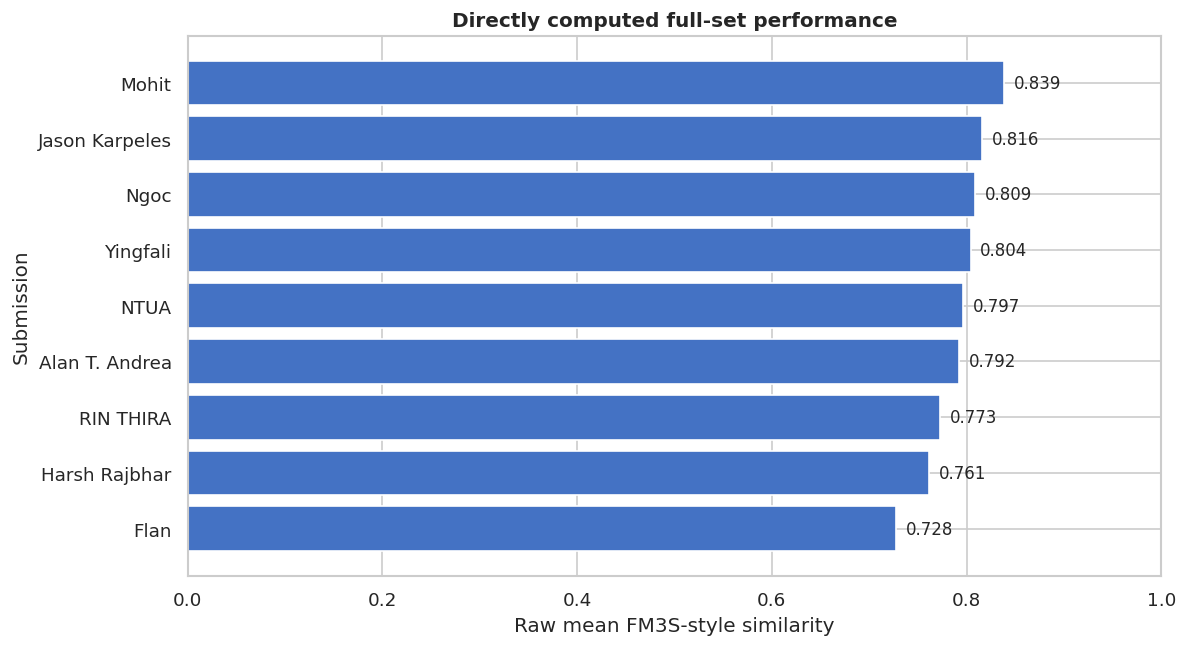

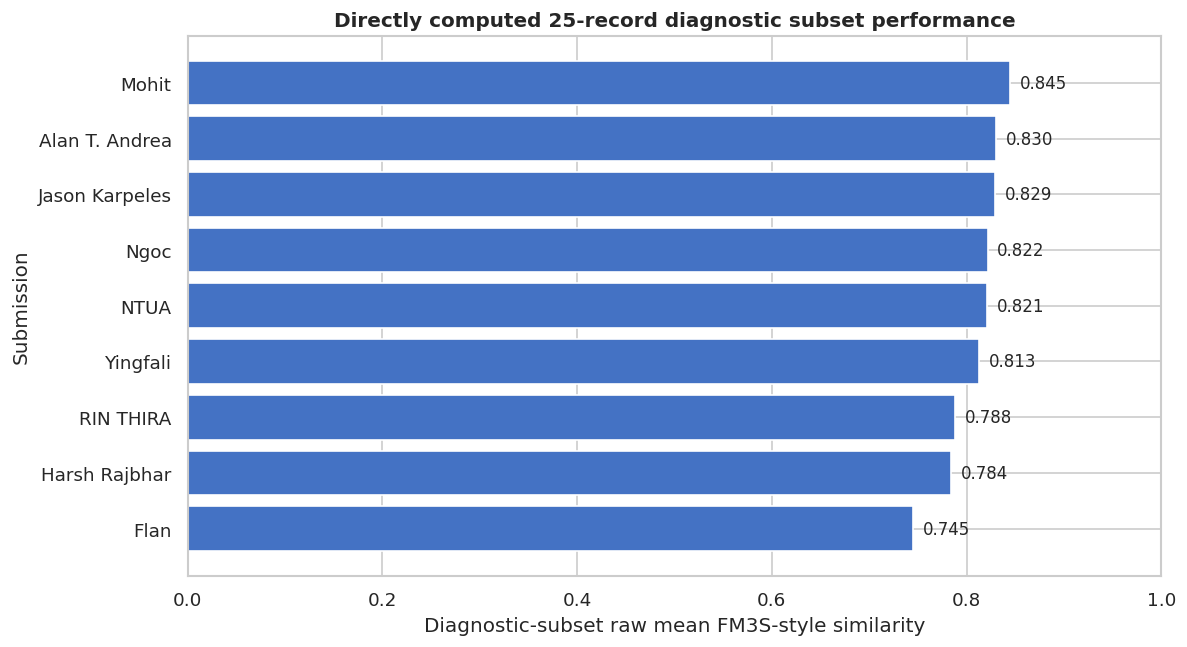

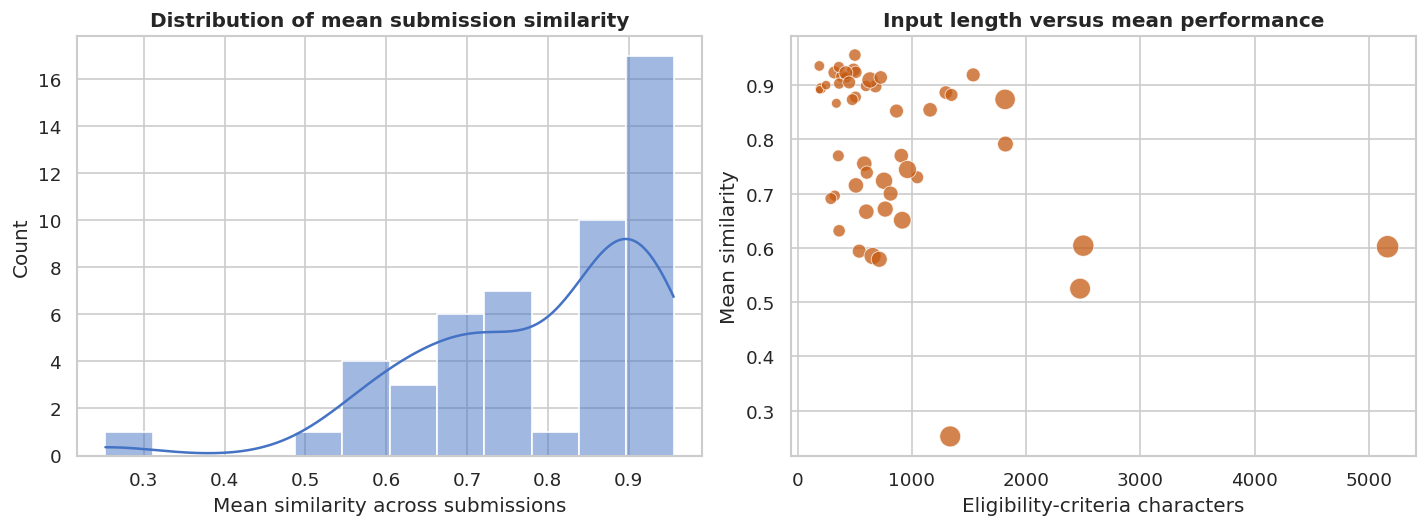

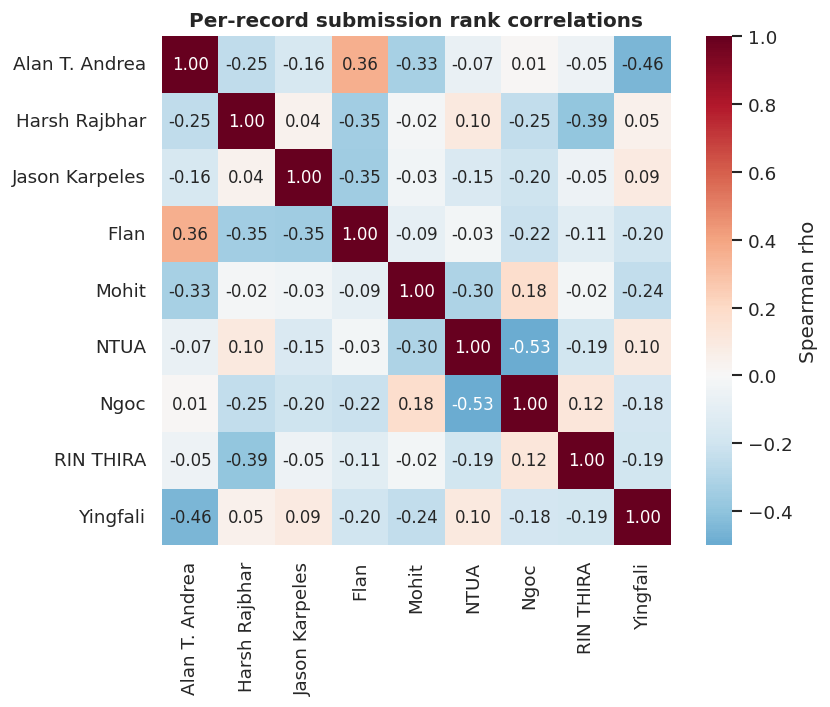

In [ ]:
def barfig(values,value_col,xlabel,title,filename):
    d=values.sort_values(value_col)
    fig,ax=plt.subplots(figsize=(10,5.5))
    bars=ax.barh(d['Submission'],d[value_col],color='#4472C4')
    for b,v in zip(bars,d[value_col]): ax.text(v+0.01,b.get_y()+b.get_height()/2,f'{v:.3f}',va='center')
    ax.set_xlim(0,1); ax.set_xlabel(xlabel); ax.set_ylabel('Submission'); ax.set_title(title); fig.tight_layout(); fig.savefig(OUT/filename,bbox_inches='tight'); plt.show()

barfig(leaderboard[leaderboard['Submission'].isin(model_names)],'Raw mean','Raw mean FM3S-style similarity','Directly computed full-set performance','figure_full_set_direct.png')
barfig(private.rename(columns={'Private raw mean':'Raw mean'}),'Raw mean','Diagnostic-subset raw mean FM3S-style similarity','Directly computed 25-record diagnostic subset performance','figure_private_direct.png')

fig,axes=plt.subplots(1,2,figsize=(12,4.5))
sns.histplot(row_summary['mean_submission_score'],bins=12,kde=True,ax=axes[0],color='#4472C4')
axes[0].set_title('Distribution of mean submission similarity'); axes[0].set_xlabel('Mean similarity across submissions')
sns.scatterplot(data=row_summary,x='criteria_chars',y='mean_submission_score',size='reference_triples',sizes=(25,180),alpha=.75,ax=axes[1],color='#C55A11',legend=False)
axes[1].set_title('Input length versus mean performance'); axes[1].set_xlabel('Eligibility-criteria characters'); axes[1].set_ylabel('Mean similarity')
fig.tight_layout(); fig.savefig(OUT/'figure_record_difficulty_direct.png',bbox_inches='tight'); plt.show()

fig,ax=plt.subplots(figsize=(7.5,6))
sns.heatmap(rank_correlations,vmin=-0.5,vmax=1,cmap='RdBu_r',center=0,annot=True,fmt='.2f',square=True,ax=ax,cbar_kws={'label':'Spearman rho'})
ax.set_title('Per-record submission rank correlations'); fig.tight_layout(); fig.savefig(OUT/'figure_rank_correlations_direct.png',bbox_inches='tight'); plt.show()


## 10. Reproducibility statement

All computed objects above are derived from `Solution.csv` and the nine submission CSVs. The notebook creates `computed_outputs/` only as an output directory. It does not read any precomputed leaderboard, row-score, private-subset, uncertainty, comparison, record-extreme, or correlation artifact.

The direct scorer is intentionally identified as an FM3S-style reimplementation because the official evaluator and raw row-level official scores were not supplied. Consequently, direct scores should not be silently presented as the official leaderboard scores. The official 25-row private-subset membership is also unavailable in the CSV inputs; the first 25 aligned rows are used only as a clearly labeled diagnostic subset.